In [57]:
# Import the required packages
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import numpy as np
import seaborn as sns

In [59]:
# Load the data and read the head
data = pd.read_csv('Week 2 - Practice - BTC minutely quotes.csv')
data.head()

,date,startTime,endTime,sym,lastVanillaMid,lastBid,lastAsk,lastShift,lastPreVim,lastAlpha,lastTrigger,lastDispersion
0,2025.02.05,2025.02.05D00:00:00.000000000,2025.02.05D00:01:00.000000000,BTCUSD,97893.728750,97901.8300,97901.830000,0.69,97900.483417,NaN,coinbase (UDP Channel),0.0
1,2025.02.05,2025.02.05D00:01:00.000000000,2025.02.05D00:02:00.000000000,BTCUSD,97882.568389,97887.6600,97888.060000,0.52,97887.658283,NaN,coinbase (UDP Channel),0.0
2,2025.02.05,2025.02.05D00:02:00.000000000,2025.02.05D00:03:00.000000000,BTCUSD,97881.234308,97887.9900,97888.344344,0.69,97887.988113,NaN,coinbase (UDP Channel),0.0
3,2025.02.05,2025.02.05D00:03:00.000000000,2025.02.05D00:04:00.000000000,BTCUSD,97917.533847,97923.6600,97923.660000,0.58,97923.213064,NaN,binance2 (UDP Channel),0.0
4,2025.02.05,2025.02.05D00:04:00.000000000,2025.02.05D00:05:00.000000000,BTCUSD,98007.666629,98013.0483,98013.450000,0.59,98013.449081,NaN,okexcash (UDP Channel),0.0


In [61]:
# Determine what type of data we are dealing with
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            60 non-null     object 
 1   startTime       60 non-null     object 
 2   endTime         60 non-null     object 
 3   sym             60 non-null     object 
 4   lastVanillaMid  60 non-null     float64
 5   lastBid         60 non-null     float64
 6   lastAsk         60 non-null     float64
 7   lastShift       60 non-null     float64
 8   lastPreVim      60 non-null     float64
 9   lastAlpha       0 non-null      float64
 10  lastTrigger     60 non-null     object 
 11  lastDispersion  60 non-null     float64
dtypes: float64(7), object(5)
memory usage: 5.8+ KB


In [63]:
# Get an overview of the data
data.describe()

,lastVanillaMid,lastBid,lastAsk,lastShift,lastPreVim,lastAlpha,lastDispersion
count,60.000000,60.000000,60.000000,60.000000,60.000000,0.0,60.0
mean,98101.083198,98110.533588,98110.653166,0.976333,98110.509350,NaN,0.0
std,148.821759,154.101101,154.054366,0.704891,153.969301,NaN,0.0
min,97804.292442,97809.670000,97809.893917,0.230000,97809.671678,NaN,0.0
25%,97991.728805,97996.977500,97996.977500,0.550000,97997.436838,NaN,0.0
50%,98119.557807,98124.980000,98125.205000,0.590000,98125.150622,NaN,0.0
75%,98212.125376,98219.900000,98219.978383,1.390000,98219.810557,NaN,0.0
max,98377.616158,98398.030000,98398.080000,2.920000,98398.078702,NaN,0.0


In [65]:
# Determine how many tokens were traded
data['sym'].unique()

array(['BTCUSD'], dtype=object)

In [67]:
# Determine how many NaN values there are
data.isna().sum()

date               0
startTime          0
endTime            0
sym                0
lastVanillaMid     0
lastBid            0
lastAsk            0
lastShift          0
lastPreVim         0
lastAlpha         60
lastTrigger        0
lastDispersion     0
dtype: int64

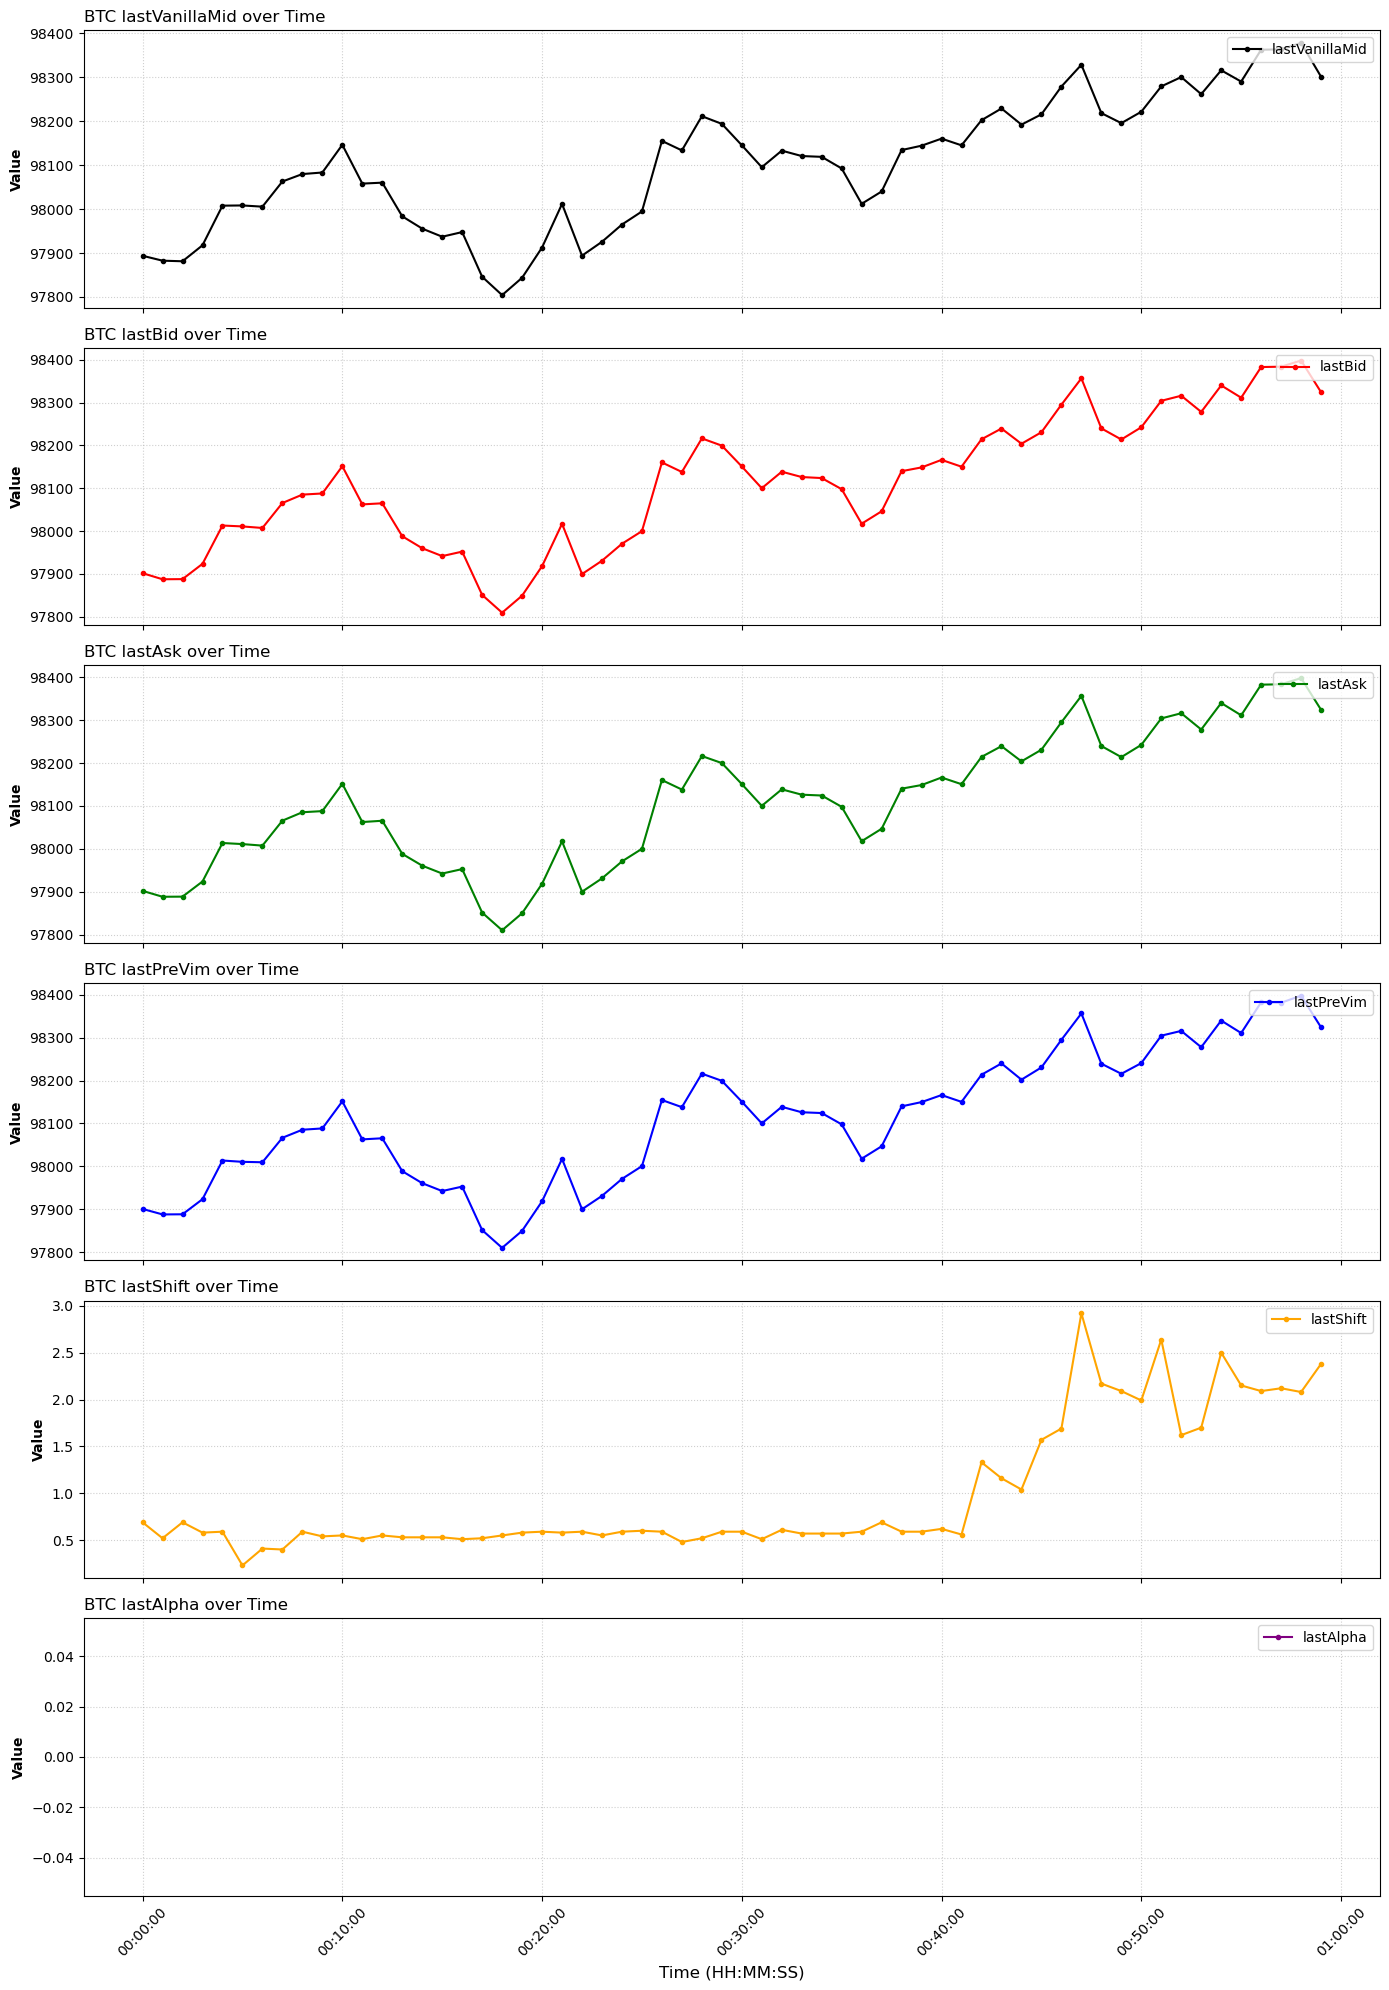

In [69]:
# Plotting the data
# We cast to string first to avoid 'AttributeError' if the column isn't purely strings
data['startTime'] = pd.to_datetime(data['startTime'].astype(str).str.replace('D', ' '), errors='coerce')

# Define the variables we want to plot
vars_to_plot = ['lastVanillaMid', 'lastBid', 'lastAsk', 'lastPreVim', 'lastShift', 'lastAlpha']
colours = ['black', 'red', 'green', 'blue', 'orange', 'purple']

# Create a vertical stack of subplots (6 rows, 1 column)
fig, axes = plt.subplots(len(vars_to_plot), 1, figsize=(14, 20), sharex=True)

for i, var in enumerate(vars_to_plot):
    if var in data.columns:
        # Plot the data
        axes[i].plot(data['startTime'], data[var], marker='.', color=colours[i], label=var, linewidth=1.5)
        
        # Labeling and styling
        axes[i].set_ylabel('Value', fontweight='bold')
        axes[i].set_title(f'BTC {var} over Time', fontsize=12, loc='left')
        axes[i].grid(True, linestyle=':', alpha=0.6)
        axes[i].legend(loc='upper right')
        
        # If the variable is a price, you might want to adjust the Y-axis padding
        if 'last' in var and 'Shift' not in var and 'Alpha' not in var:
             axes[i].ticklabel_format(useOffset=False, style='plain', axis='y')

# Format the X-axis (shared across all plots)
axes[-1].set_xlabel('Time (HH:MM:SS)', fontsize=12)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Final Cumulative Counts:
binance2 (UDP Channel)           6
binancefutures (UDP Channel)     3
coinbase (UDP Channel)          28
huobi (UDP Channel)              1
netRisk                          1
okexcash (UDP Channel)          21
Name: 59, dtype: object


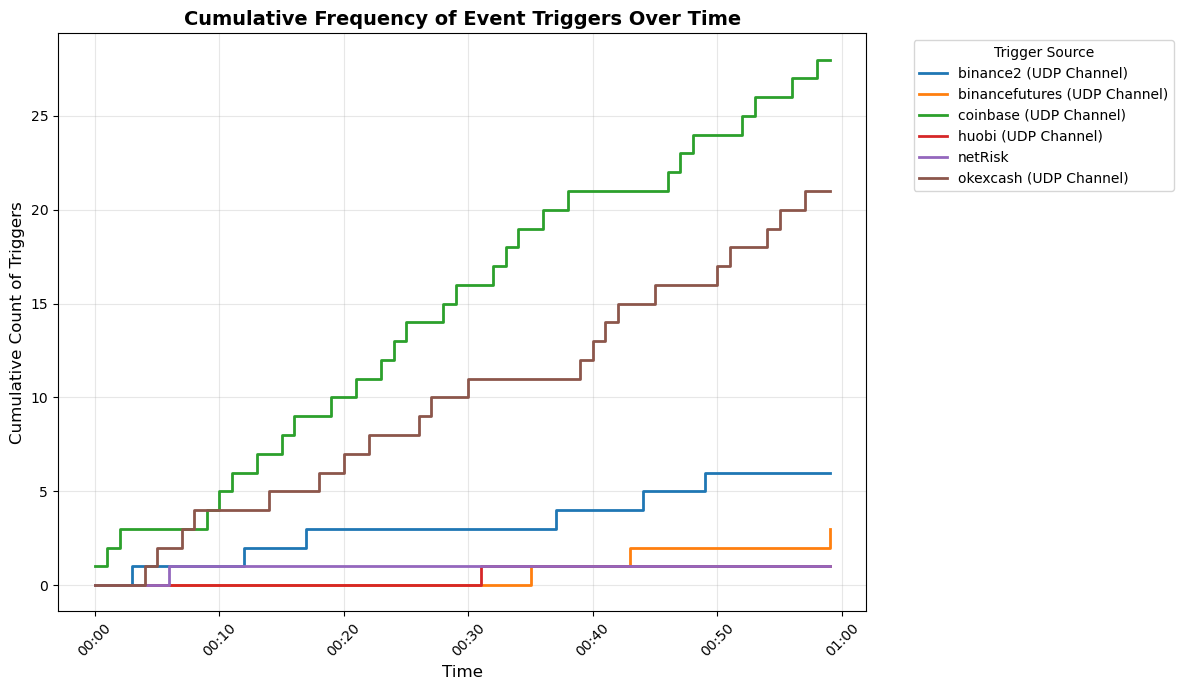

In [70]:
# Determine how often each platform was used for the last minute
# Create binary indicators for each trigger
trigger_dummies = pd.get_dummies(data['lastTrigger'])

# Calculate cumulative sum for each trigger
cumulative_triggers = trigger_dummies.cumsum()

# Add the time axis back
cumulative_triggers['startTime'] = data['startTime']

# Visualisation
plt.figure(figsize=(12, 7))

for column in trigger_dummies.columns:
    plt.step(cumulative_triggers['startTime'], cumulative_triggers[column], where='post', label=column, lw=2)

plt.title('Cumulative Frequency of Event Triggers Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Cumulative Count of Triggers', fontsize=12)
plt.legend(title='Trigger Source', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

# Format x-axis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('cumulative_triggers.png')

# Print the final counts for the user
print("Final Cumulative Counts:")
print(cumulative_triggers.iloc[-1].drop('startTime'))

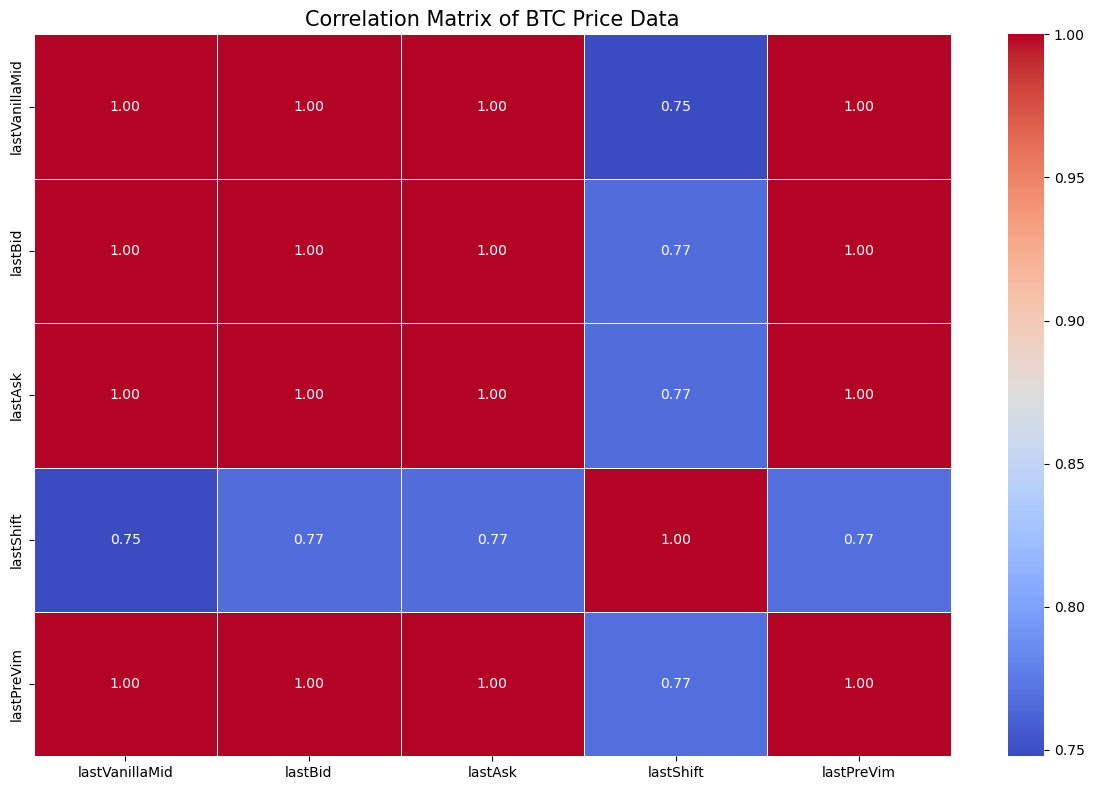

In [71]:
# View the correlation of the variables
# Select only numeric columns from the 'data' dataframe
numeric_df = data.select_dtypes(include=[np.number])

# Clean the data: Drop columns that are entirely empty or have no change
numeric_df = numeric_df.dropna(axis=1, how='all')
numeric_df = numeric_df.loc[:, (numeric_df != numeric_df.iloc[0]).any()]

# Compute the correlation matrix
corr_matrix = numeric_df.corr()

# Create the heatmap visualisation
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of BTC Price Data', fontsize=15)
plt.tight_layout()
plt.show()

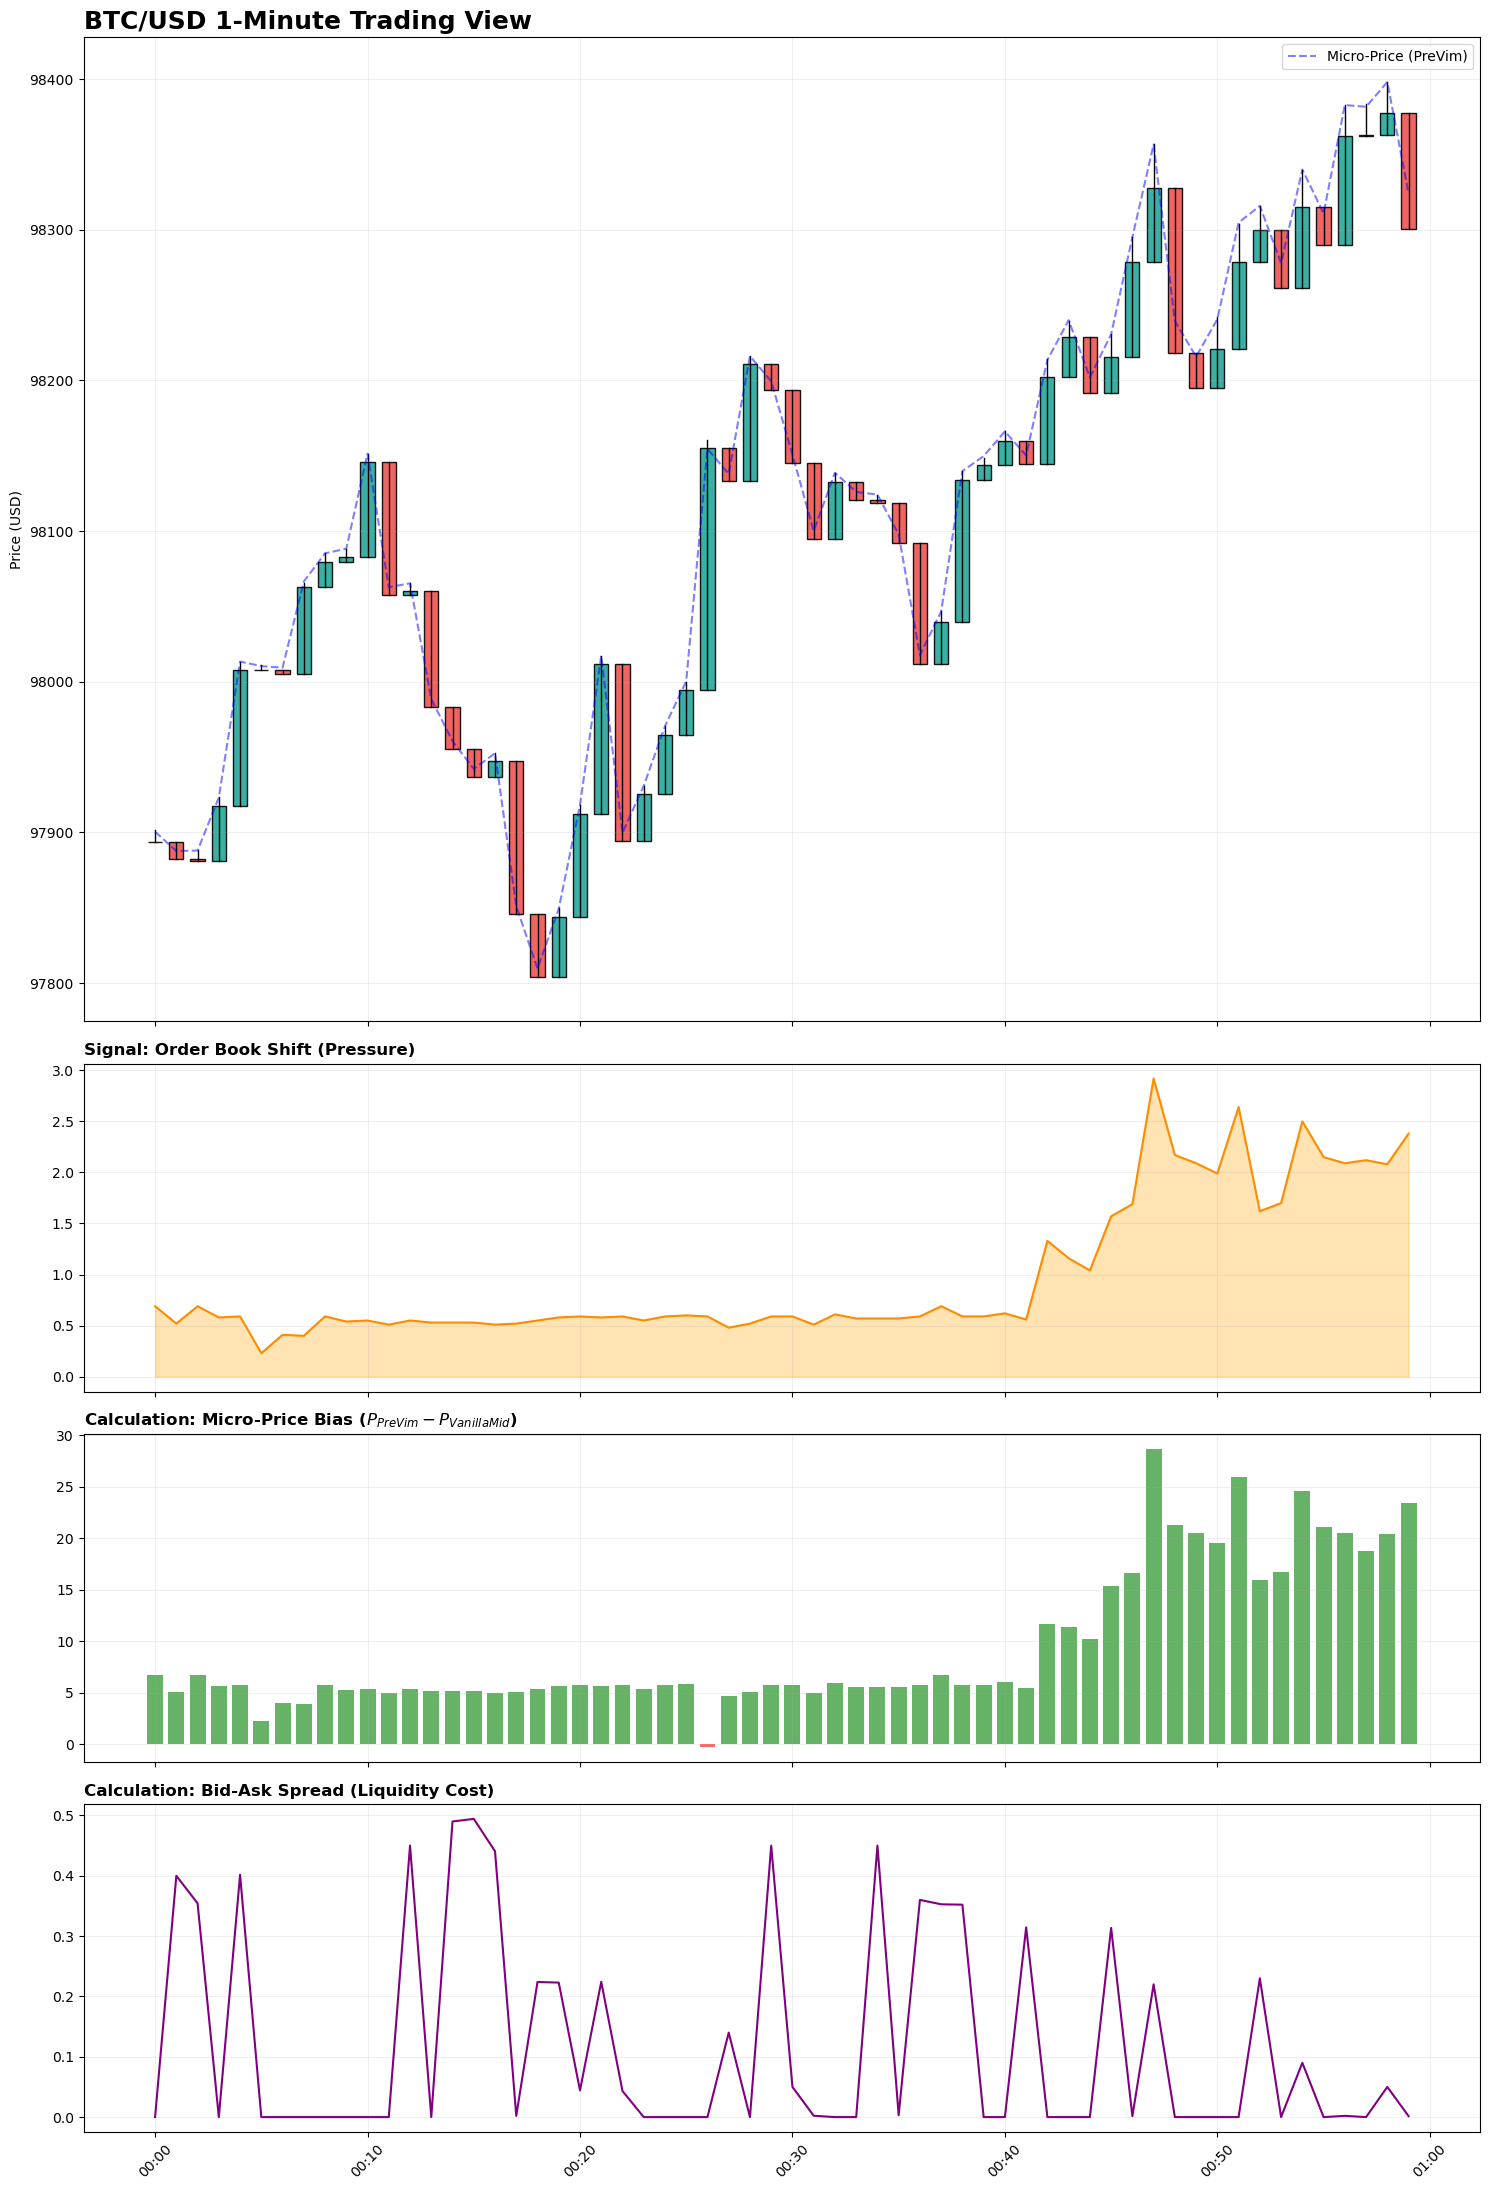

In [72]:
# Candlestick and other plots
data = data.sort_values('startTime').reset_index(drop=True)

# Determine open, close, high and low
data['close'] = data['lastVanillaMid'] # Close is the vanilla mid. Note vanilla mid is assumed to be the average of the bid and ask over the period
data['open'] = data['close'].shift(1).fillna(data['close']) # Let the opening price be the closing price of the previous period
data['high'] = data[['lastAsk', 'open', 'close']].max(axis=1) # High is the highest of the ask, open and close
data['low'] = data[['lastBid', 'open', 'close']].min(axis=1) # Low is the lowest of the bid, open, and close

# Determine micro-price bias ("hidden" pressure in the order book)
# Assuming that lastPreVim is pre volume imbalance mid, i.e. whether the price is shifting to the buyers or the sellers due to demand
data['vim_bias'] = data['lastPreVim'] - data['lastVanillaMid'] 

# Determine market spread (gives an idea of the liquidity)
data['spread'] = data['lastAsk'] - data['lastBid']

# Visualisations
fig, axes = plt.subplots(4, 1, figsize=(15, 22), sharex=True, 
                         gridspec_kw={'height_ratios': [3, 1, 1, 1]})

# Panel 1: Candlesticks & lastPreVim
ax0 = axes[0]
for i, row in data.iterrows():
    color = '#26a69a' if row['close'] >= row['open'] else '#ef5350'
    # Wicks are the 
    ax0.plot([row['startTime'], row['startTime']], [row['low'], row['high']], color='black', lw=1)
    # Body
    rect = Rectangle((row['startTime'] - pd.Timedelta(seconds=20), min(row['open'], row['close'])), 
                     pd.Timedelta(seconds=40), max(abs(row['close'] - row['open']), 0.2), 
                     facecolor=color, edgecolor='black', alpha=0.9)
    ax0.add_patch(rect)

# Overlay lastPreVim onto the candles to see the former leads the latter
ax0.plot(data['startTime'], data['lastPreVim'], color='blue', alpha=0.5, label='Micro-Price (PreVim)', linestyle='--')
ax0.set_title('BTC/USD 1-Minute Trading View', fontsize=18, fontweight='bold', loc='left')
ax0.set_ylabel('Price (USD)')
ax0.legend(loc='upper right')
ax0.grid(True, alpha=0.2)

# Panel 2: Lastshift (it is a momentum indicator that indicates how much the order book has moved and in what direction over a period)
axes[1].fill_between(data['startTime'], data['lastShift'], color='orange', alpha=0.3)
axes[1].plot(data['startTime'], data['lastShift'], color='darkorange', lw=1.5, label='Order Shift')
axes[1].set_title('Signal: Order Book Shift (Pressure)', loc='left', fontweight='bold')
axes[1].grid(True, alpha=0.2)

# Panel 3: Micro-Price Bias
# If Bias > 0, the internal order book is leaning bullish relative to the vanilla mid.
axes[2].bar(data['startTime'], data['vim_bias'], width=pd.Timedelta(seconds=45), 
           color=['green' if x > 0 else 'red' for x in data['vim_bias']], alpha=0.6)
axes[2].set_title('Calculation: Micro-Price Bias ($P_{PreVim} - P_{VanillaMid}$)', loc='left', fontweight='bold')
axes[2].grid(True, alpha=0.2)

# Panel 4: Market Spread
axes[3].plot(data['startTime'], data['spread'], color='purple', lw=1.5)
axes[3].set_title('Calculation: Bid-Ask Spread (Liquidity Cost)', loc='left', fontweight='bold')
axes[3].grid(True, alpha=0.2)

# Formatting
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

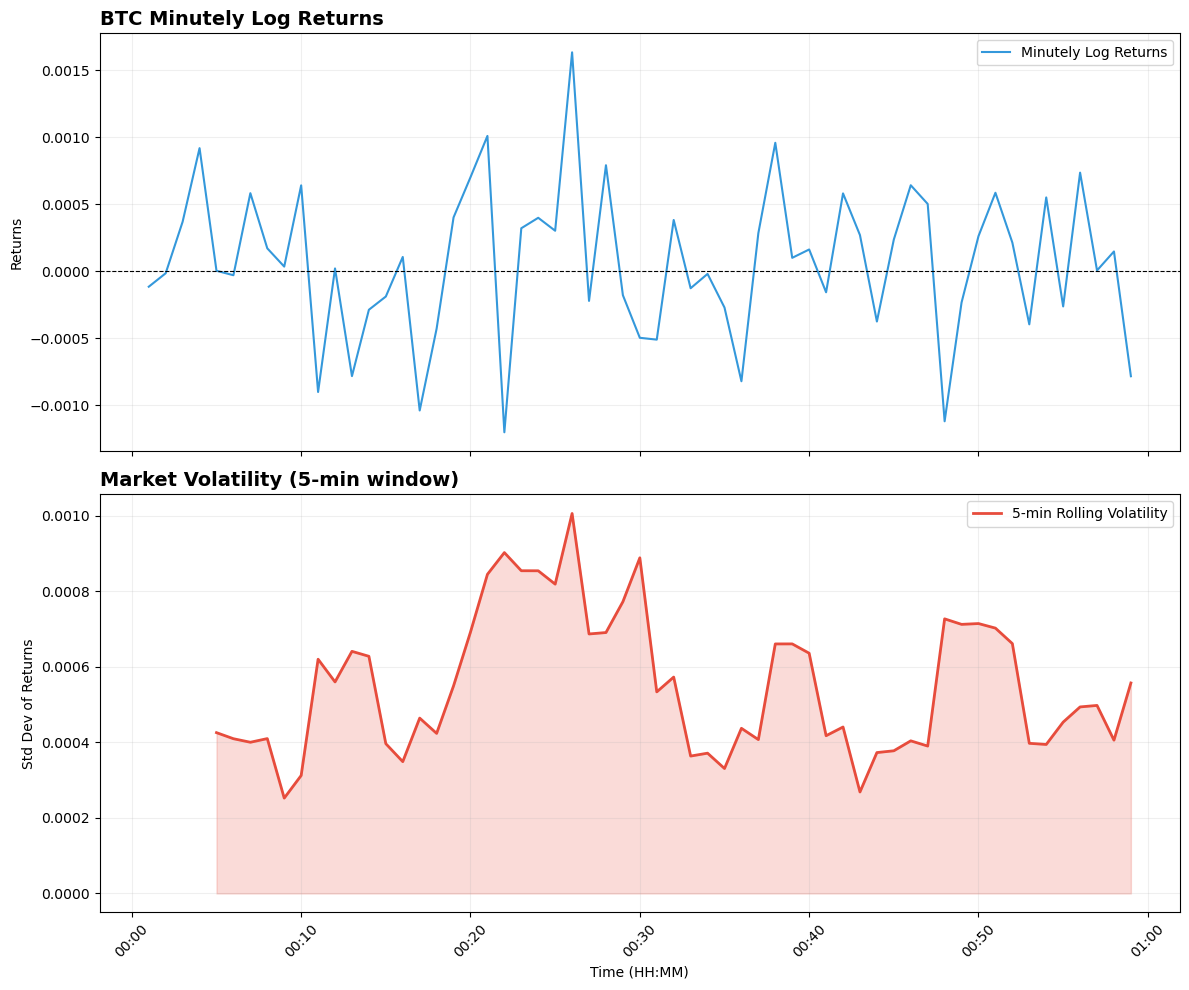

In [73]:
# Look at the returns
# Log returns are standard for financial time series
data['returns'] = np.log(data['lastVanillaMid'] / data['lastVanillaMid'].shift(1))

# Rolling Standard Deviation (Volatility) using a 5-minute window
window_size = 5
data['rolling_vol'] = data['returns'].rolling(window=window_size).std()

# Visualisation
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Plot 1: Log Returns 
ax1.plot(data['startTime'], data['returns'], color='#3498db', lw=1.5, label='Minutely Log Returns')
ax1.axhline(0, color='black', lw=0.8, linestyle='--')
ax1.set_title('BTC Minutely Log Returns', fontsize=14, fontweight='bold', loc='left')
ax1.set_ylabel('Returns')
ax1.grid(True, alpha=0.2)
ax1.legend(loc='upper right')

# Plot 2: Rolling Volatility (The 'Risk')
ax2.fill_between(data['startTime'], data['rolling_vol'], color='#e74c3c', alpha=0.2)
ax2.plot(data['startTime'], data['rolling_vol'], color='#e74c3c', lw=2, label=f'{window_size}-min Rolling Volatility')
ax2.set_title(f'Market Volatility ({window_size}-min window)', fontsize=14, fontweight='bold', loc='left')
ax2.set_ylabel('Std Dev of Returns')
ax2.set_xlabel('Time (HH:MM)')
ax2.grid(True, alpha=0.2)
ax2.legend(loc='upper right')

# Formatting the X-axis for time
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('volatility_plots.png')

1.) lastVanillaMid, lastBid, and lastAsk are almost perfectly correlated, indicating a very tight bid-ask spread during the observed period.
2.) The market is not a single entity. It is led by specific venues. Coinbase and OKX act as the primary "Triggers."
3.) Price discovery happens on these two exchanges first. If you see a move on Binance that isn't reflected in the Coinbase trigger, it is more likely to be "noise" than a real trend.
4.) High volatility is not "random", it comes in clusters. 
5.) There was a high order-book shift in the last 15 minutes or so 
6.) Over the 60-minute window, Bitcoin showed a net positive "drift"
7.) The spread is very tight over the period, given the value of BTC. While the Order Book Shift suggests the model was aggressively adjusting for price pressure at the end of the session, the Spread Plot confirms this movement was backed by deep liquidity. The fact that spreads remained tight during the final momentum spike confirms that the price move was 'orderly' and well-supported by market makers.